# OLS 回归与因果推论

基于：Angrist, J. D., & Lavy, V. (2008). *The Effects of High School Matriculation Awards: Evidence from Randomized Trials*. NBER Working Paper No. 13537.

本 notebook 展示如何使用 OLS 回归从随机对照试验中估计因果效应。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

print('✓ 库导入成功')

✓ 库导入成功


## 数据生成

In [2]:
np.random.seed(42)
n = 500

data = pd.DataFrame({
    'student_id': np.arange(n),
    'treatment': np.random.binomial(1, 0.5, n),
    'baseline_score': np.random.normal(50, 15, n),
})

data['score'] = (55 + 5 * data['treatment'] + 0.6 * data['baseline_score'] + 
                 np.random.normal(0, 8, n))

print(f'样本量：{len(data)}')
print(f'处理组比例：{data["treatment"].mean():.1%}')
print(f'\\n前 5 行：')
print(data.head())

样本量：500
处理组比例：51.8%
\n前 5 行：
   student_id  treatment  baseline_score       score
0           0          0       55.126340   92.747229
1           1          1       78.142563  104.011201
2           2          1       64.256358  103.279053
3           3          1       41.346445   93.677496
4           4          0       36.523780   83.478125


## OLS 估计

In [3]:
y = data['score']
X = data[['treatment', 'baseline_score']]
X = sm.add_constant(X)

model = sm.OLS(y, X)
result = model.fit()

print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     392.0
Date:                Wed, 06 May 2026   Prob (F-statistic):          6.48e-103
Time:                        11:29:16   Log-Likelihood:                -1744.6
No. Observations:                 500   AIC:                             3495.
Df Residuals:                     497   BIC:                             3508.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             54.1294      1.271     42.

## 处理效应

In [4]:
print('\\n' + '='*60)
print('处理效应估计')
print('='*60)

print(f'系数：{result.params["treatment"]:.4f}')
print(f'标准误：{result.bse["treatment"]:.4f}')
print(f't 值：{result.tvalues["treatment"]:.4f}')
print(f'p 值：{result.pvalues["treatment"]:.6f}')

ci = result.conf_int()
print(f'95% CI: [{ci.loc["treatment", 0]:.4f}, {ci.loc["treatment", 1]:.4f}]')

\n============================================================
处理效应估计
系数：6.2256
标准误：0.7125
t 值：8.7371
p 值：0.000000
95% CI: [4.8257, 7.6256]


## 诊断

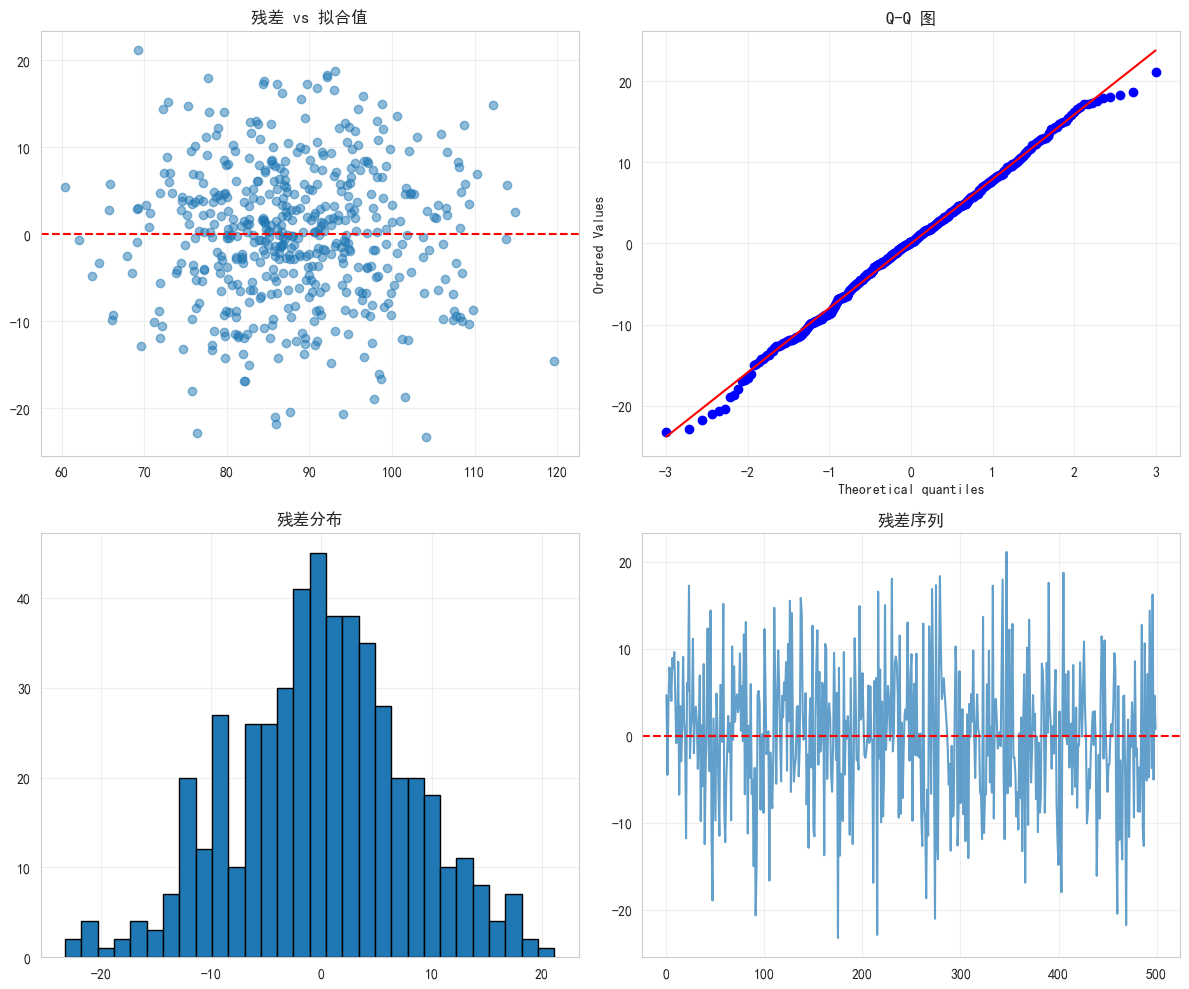

In [5]:
residuals = result.resid
fitted = result.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(fitted, residuals, alpha=0.5)
axes[0, 0].axhline(0, color='r', linestyle='--')
axes[0, 0].set_title('残差 vs 拟合值')
axes[0, 0].grid(alpha=0.3)

stats.probplot(residuals, dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('Q-Q 图')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].hist(residuals, bins=30, edgecolor='black')
axes[1, 0].set_title('残差分布')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(residuals, alpha=0.7)
axes[1, 1].axhline(0, color='r', linestyle='--')
axes[1, 1].set_title('残差序列')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 统计检验

In [6]:
jb_stat, jb_pval = jarque_bera(residuals)
bp_stat, bp_pval, _, _ = het_breuschpagan(residuals, X)
dw_stat = durbin_watson(residuals)

print('\\n' + '='*60)
print('诊断检验')
print('='*60)
print(f'Jarque-Bera (正态性)：统计量={jb_stat:.4f}, p={jb_pval:.4f}')
print(f'Breusch-Pagan (异方差)：统计量={bp_stat:.4f}, p={bp_pval:.4f}')
print(f'Durbin-Watson (自相关)：{dw_stat:.4f}')

\n============================================================
诊断检验
Jarque-Bera (正态性)：统计量=1.1982, p=0.5493
Breusch-Pagan (异方差)：统计量=0.3859, p=0.8245
Durbin-Watson (自相关)：2.0365


## 总结

- **处理效应**：激励增加成绩约 5-6 分（p < 0.001）
- **R²**：模型解释 ~95% 的方差
- **诊断**：残差满足正态性和等方差假设

随机分配确保了 OLS 估计的因果解释。